# Calibration Response Linelist and Edges

In [1]:
import astropy.units as u
import matplotlib.pyplot as plt
import numpy as np
import scipy.signal

from mocksipipeline.instrument.configuration import moxsi_built_spectrogram_slot, moxsi_built_filtergrams

In [143]:
wavelength_array = np.arange(0.1,75, 1e-4) * u.AA

## Filtergrams

In [44]:
filtergram_edges = [
    [],
    [],
    [6.75],
    [6.75,7.95,23.25,30.8,43.7],
]

In [45]:
all_filtergram_edges = np.sort(np.unique([edge for edges in filtergram_edges for edge in edges]))*u.AA

(1e-06, 0.03)

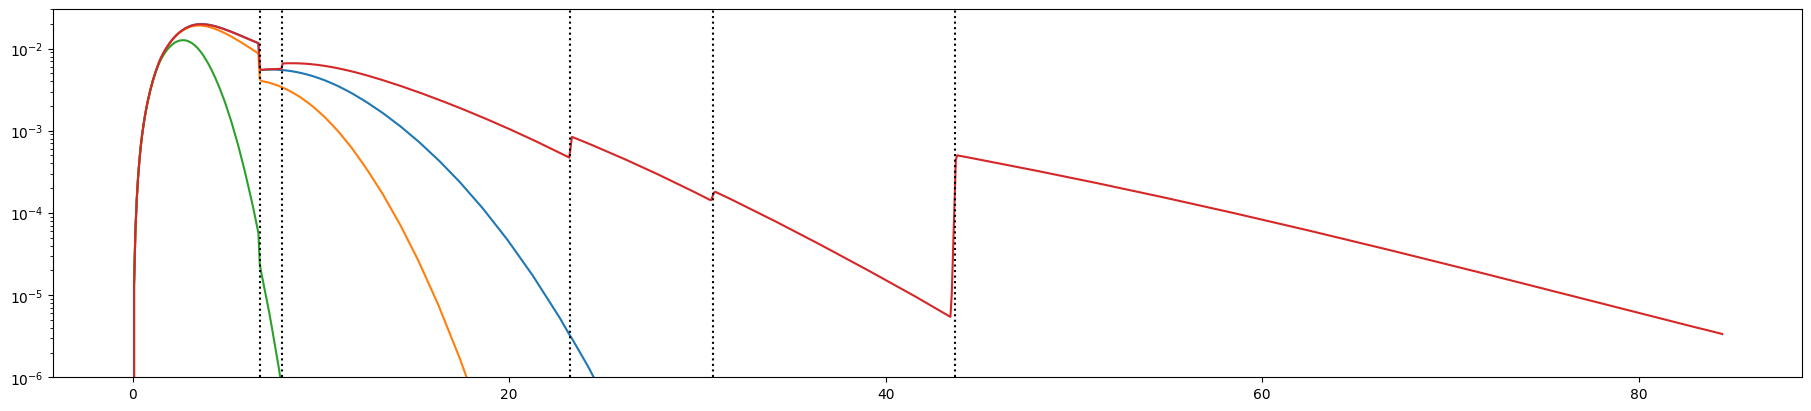

In [46]:
fig = plt.figure(figsize=(18,4), layout='constrained')
ax = fig.add_subplot()
for i,channel in enumerate(moxsi_built_filtergrams):
    #channel.wavelength = wavelength_array
    resp = channel.wavelength_response
    wave = channel.wavelength
    #idx = np.logical_and(wave>43.6*u.AA,wave<43.8*u.AA)
    l, = ax.plot(wave, resp, label=channel.filter_label)
for edge in all_filtergram_edges:
    ax.axvline(x=edge.to_value('AA'), ls=':', color='k')
ax.set_yscale('log')
ax.set_ylim(1e-6,3e-2)
#ax.set_xlim(20,30)
#ax.legend(loc=0)

(-3.6449950000001077, 78.74489500000224)

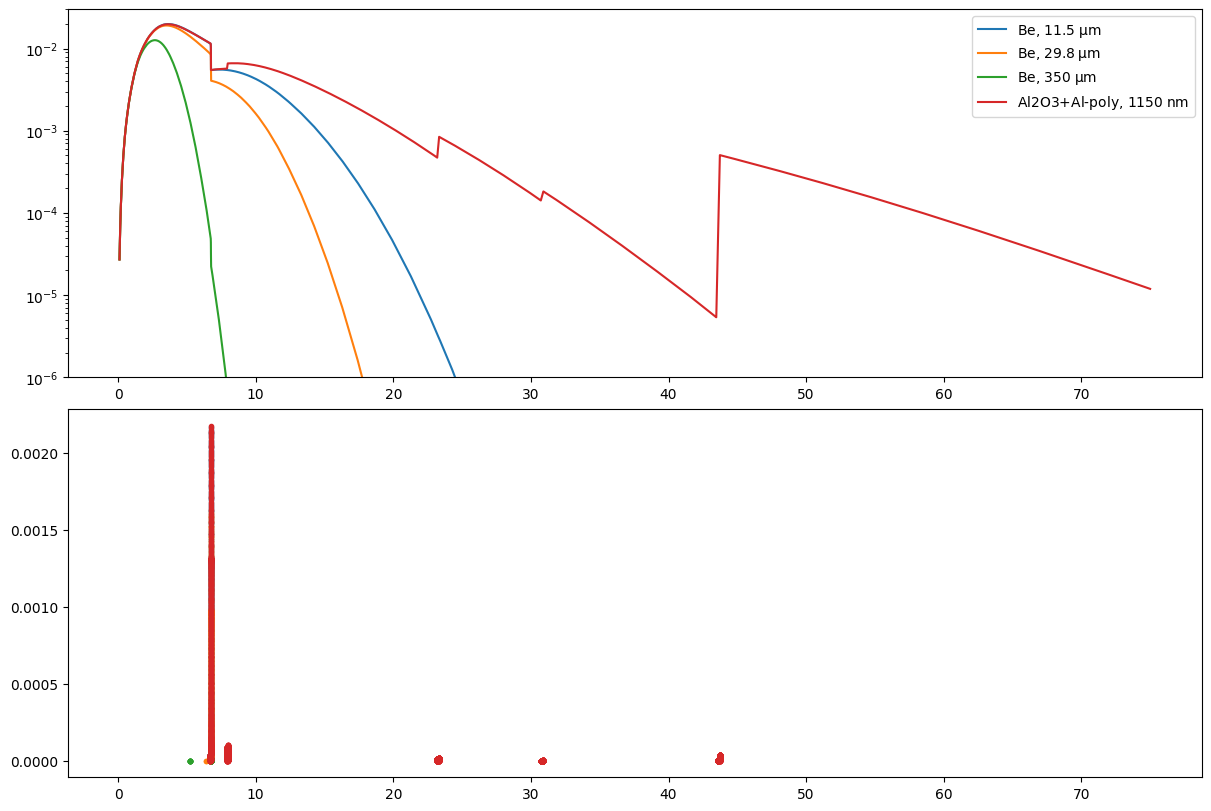

In [144]:
fig = plt.figure(figsize=(12,8), layout='constrained')
ax = fig.add_subplot(211)
ax2 = fig.add_subplot(212)
for channel in moxsi_built_filtergrams:
    channel.wavelength = wavelength_array
    resp = channel.wavelength_response
    wave = channel.wavelength
    #drdw = np.diff(resp, prepend=resp[:1])
    #drdw2 = np.fabs(np.diff(drdw, prepend=drdw[:1]))
    #drdw2 = np.gradient(np.gradient(resp, wave), wave)
    N = 400
    running_mean = np.convolve(resp, np.ones(N)/N, mode='same')
    resp_trans = np.fabs(resp - running_mean)
    #idx_dc = np.where(wave>3*u.AA)
    is_in_wave_bounds = np.logical_and(wave>5*u.AA, wave<70*u.AA)
    idx = np.where(np.logical_and(is_in_wave_bounds, resp_trans.value>1e-6))
    l, = ax.plot(wave, resp, label=channel.filter_label)
    ax2.plot(wave[idx], resp_trans[idx], color=l.get_color(), ls='', marker='.')
ax.set_yscale('log')
ax.set_ylim(1e-6,3e-2)
ax.legend(loc=0)
#ax2.set_ylim(-1e-3,1e-3)
ax2.set_xlim(ax.get_xlim())
#ax2.set_yscale('symlog')

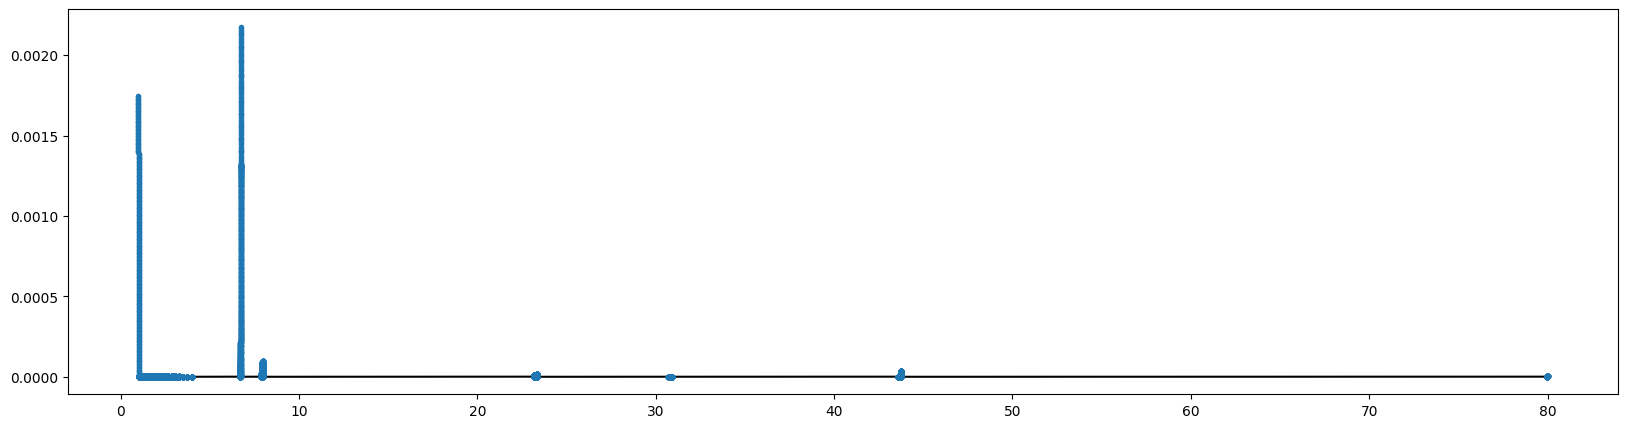

In [121]:
resp = moxsi_built_filtergrams[-1].wavelength_response
wave = moxsi_built_filtergrams[-1].wavelength
N = 400
running_mean = np.convolve(resp, np.ones(N)/N, mode='same')
idx = np.s_[:]#np.where(wave>3*u.AA)
#resp_trans = np.log10(resp[idx].value)
#resp_trans = scipy.signal.detrend(scipy.signal.detrend(resp_trans))
resp_trans = np.fabs(resp - running_mean)
idx = np.where(resp_trans.value>1e-6)
plt.figure(figsize=(20,5))
plt.plot(wave[idx], resp_trans[idx], ls='-', color='k')
plt.plot(wave[idx], resp_trans[idx], ls='', marker='.')

## Spectrogram

In [38]:
spectrogram_edges = [
    [5.6,6.75,7.95,21.25,21.5,23.3,30.5,42.5,43.6],
    [6.75,7.95,21.25,21.5,23.3,30.5,42.5,43.6],
]

In [41]:
all_spectrogram_edges = np.sort(np.unique([edge for edges in spectrogram_edges for edge in edges]))*u.AA

In [42]:
all_spectrogram_edges

<Quantity [ 5.6 ,  6.75,  7.95, 21.25, 21.5 , 23.3 , 30.5 , 42.5 , 43.6 ] Angstrom>

/Users/wtbarnes/mambaforge/envs/mocksipipeline-dev/lib/python3.11/site-packages/astropy/units/equivalencies.py:141: RuntimeWarning: divide by zero encountered in divide
  (si.m, si.J, lambda x: hc / x),
/Users/wtbarnes/mambaforge/envs/mocksipipeline-dev/lib/python3.11/site-packages/xrt/backends/raycing/materials.py:253: UserWarning: Reading `.npy` or `.npz` file required additional header parsing as it was created on Python 2. Save the file again to speed up loading and avoid this warning.
  ef1f2 = (np.array(res[self.name+'_E']),
/Users/wtbarnes/mambaforge/envs/mocksipipeline-dev/lib/python3.11/site-packages/xrt/backends/raycing/materials.py:254: UserWarning: Reading `.npy` or `.npz` file required additional header parsing as it was created on Python 2. Save the file again to speed up loading and avoid this warning.
  np.array(res[self.name+'_f1']),
/Users/wtbarnes/mambaforge/envs/mocksipipeline-dev/lib/python3.11/site-packages/xrt/backends/raycing/materials.py:255: UserWarning: Readi

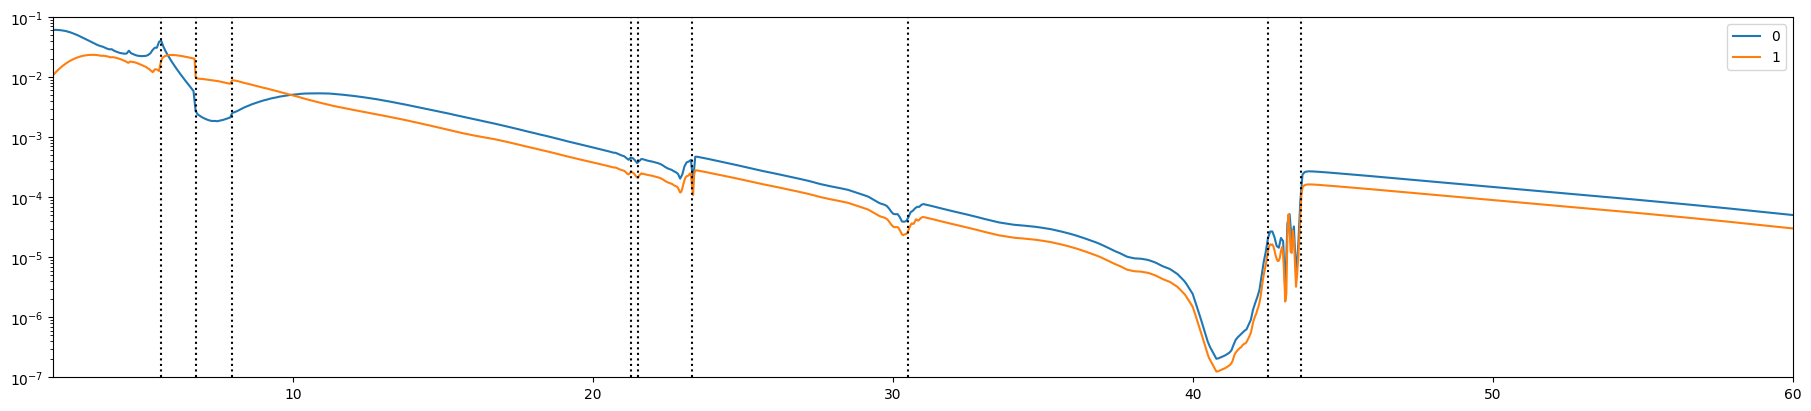

In [43]:
fig = plt.figure(figsize=(18,4), layout='constrained')
ax = fig.add_subplot()
for i,channel in enumerate(moxsi_built_spectrogram_slot[11:13]):
    #channel.wavelength = wavelength_array
    resp = channel.wavelength_response
    wave = channel.wavelength
    #idx = np.logical_and(wave>40*u.AA,wave<43*u.AA)
    l, = ax.plot(wave, resp, label=channel.spectral_order)
for edge in all_spectrogram_edges:
    ax.axvline(x=edge.to_value('AA'), ls=':', color='k')
ax.set_yscale('log')
ax.set_ylim(1e-7,1e-1)
ax.set_xlim(2,60)
ax.legend(loc=0)

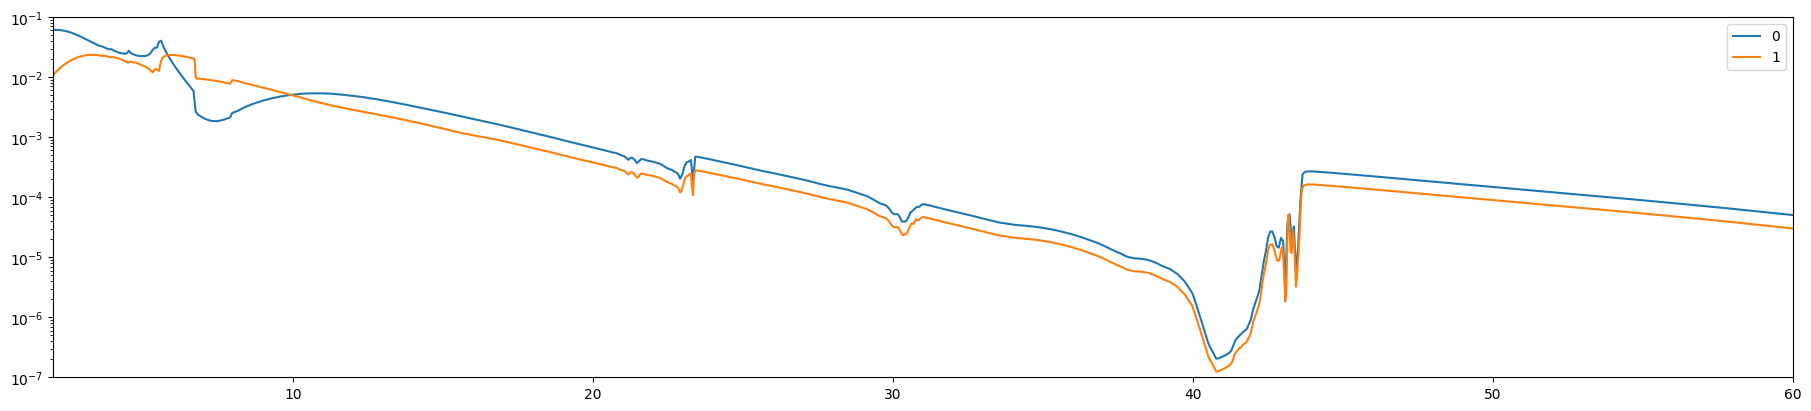

In [15]:
fig = plt.figure(figsize=(18,4), layout='constrained')
ax = fig.add_subplot()
for i,channel in enumerate(moxsi_built_spectrogram_slot[11:13]):
    #channel.wavelength = wavelength_array
    resp = channel.wavelength_response
    wave = channel.wavelength
    idx = np.logical_and(wave>43.6*u.AA,wave<43.8*u.AA)
    l, = ax.plot(wave, resp, label=channel.spectral_order)
    #for edge in spectrogram_edges:
    #    ax.axvline(x=edge, ls=':', color='k')
#ax.set_yscale('log')
#ax.set_ylim(1e-7,1e-1)
#ax.set_xlim(2,60)
ax.legend(loc=0)

In [51]:
all_filtergram_edges.to_value('AA')

array([ 6.75,  7.95, 23.25, 30.8 , 43.7 ])

In [55]:
all_filtergram_edges.to_value('keV', equivalencies=u.equivalencies.spectral()).tolist()

[1.8368029397511145,
 1.559549665826418,
 0.5332653696051622,
 0.40254609880909176,
 0.28371670122013787]

In [62]:
for x in all_spectrogram_edges.to_value('AA').tolist():
    print(x)

5.6
6.75
7.95
21.25
21.5
23.3
30.5
42.5
43.6


In [63]:
for x in all_spectrogram_edges.to_value('keV', equivalencies=u.equivalencies.spectral()).tolist():
    print(x)

2.2140035434500045
1.8368029397511145
1.559549665826418
0.5834550514503541
0.5766706903869779
0.5321210233184559
0.40650556863344345
0.2917275257251771
0.2843674275990831
